# Regular 1

| | |
|---|---|
| **Thời gian** | 90 phút |
| **Tổng điểm** | **10,0 điểm** |
| **Hình thức** | Làm trực tiếp trên notebook này. Không xóa đề. |

---

### Rules
1. Import các thư viện đã học.
2. Mọi nhận xét viết ngắn gọn, dựa trên **kết quả bạn vừa tính** — không copy insight có sẵn.
3. Chạy cell **theo thứ tự từ trên xuống**.
4. Biểu đồ phải có title và nhãn trục. In kết quả số ra màn hình.
5. Lưu file ở ổ T, đặt tên file MSSV_HoTen.ipynb.

### Cách chấm / Grading
- Code không chạy được: 0 điểm.

### Bảng điểm tóm tắt

| Phần | Nội dung | Điểm |
|---|---|---|
| 0 | Import, load, copy | 0,5 |
| 1 | Inspection (explore, duplicate, missing) | 2,0 |
| 2 | Data cleaning (missing, dtype, feature) | 3,5 |
| 3 | EDA (top items, outlier, correlation) | 3,0 |
| 4 | Summary & insights | 1,0 |
| **Tổng** | | **10,0** |

## Dataset Description 

- **Transaction ID**: mã giao dịch
- **Item**: món (Coffee, Cake, Cookie, Salad, …)
- **Quantity**: số lượng
- **Price Per Unit**: đơn giá
- **Total Spent**: tổng tiền dòng
- **Payment Method**: Credit Card / Cash / Digital Wallet
- **Location**: Takeaway hoặc In-store
- **Transaction Date**: ngày giao dịch


---
## Phần 0 — Prepare Data (**0,5 đ**)


Import thư viện cần dùng. Đọc file dirty_cafe_sales.csv.

In [37]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np

In [38]:
df = pd.read_csv("dirty_cafe_sales.csv")

Make a copy from df

In [39]:
df_original = df.copy()

---
## Phần 1 — Initial Data Inspection (**2,0 đ**)

### Câu 1.1 — Explore the data (**0,5 đ**)


In **10 dòng đầu**

In [40]:
#Your code here
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In **thông tin dataframe** (số dòng, cột, dtype, non-null).

In [41]:
# Your code here
df.shape

(10000, 8)

Cho biết **giá trị duy nhất** mỗi cột

In [42]:
# Your code here
dict = {i : df[i].unique() for i in df.columns}
dict

{'Transaction ID': <StringArray>
 ['TXN_1961373', 'TXN_4977031', 'TXN_4271903', 'TXN_7034554', 'TXN_3160411',
  'TXN_2602893', 'TXN_4433211', 'TXN_6699534', 'TXN_4717867', 'TXN_2064365',
  ...
  'TXN_1538510', 'TXN_3897619', 'TXN_2739140', 'TXN_4766549', 'TXN_7851634',
  'TXN_7672686', 'TXN_9659401', 'TXN_5255387', 'TXN_7695629', 'TXN_6170729']
 Length: 10000, dtype: str,
 'Item': <StringArray>
 [  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'UNKNOWN',
  'Sandwich',        nan,    'ERROR',    'Juice',      'Tea']
 Length: 11, dtype: str,
 'Quantity': <StringArray>
 ['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan]
 Length: 8, dtype: str,
 'Price Per Unit': <StringArray>
 ['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN']
 Length: 9, dtype: str,
 'Total Spent': <StringArray>
 [    '4.0',    '12.0',   'ERROR',    '10.0',    '20.0',     '9.0',    '16.0',
     '15.0',    '25.0',     '8.0',     '5.0',     '3.0',     '6.0',       nan,
  'UNKNOWN',     '2.0', 

### Câu 1.2 — Duplicate (**0,5 đ**)

**Yêu cầu**
- Đếm số dòng trùng. Nếu có: quyết định xóa hay giữ, chạy code, giải thích, và so sánh dữ liệu trước/sau xóa.



In [43]:
#  Your code here
print(df.duplicated().sum())
#Không bị trùng lặp dữ liệu

0


In [44]:
df.shape[0]

10000

In [45]:
df.shape[1]

8

### Câu 1.3 — Missing values (**1,0 đ**)

**Yêu cầu**
1. Đếm missing **theo từng cột** (**0,3 đ**).
2. Tính **% missing trên toàn bộ dataset** (**0,3 đ**).
3. Vẽ **bar chart** missing (**0,4 đ**).

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64
% trên tổng dataset:  68.26


<Axes: >

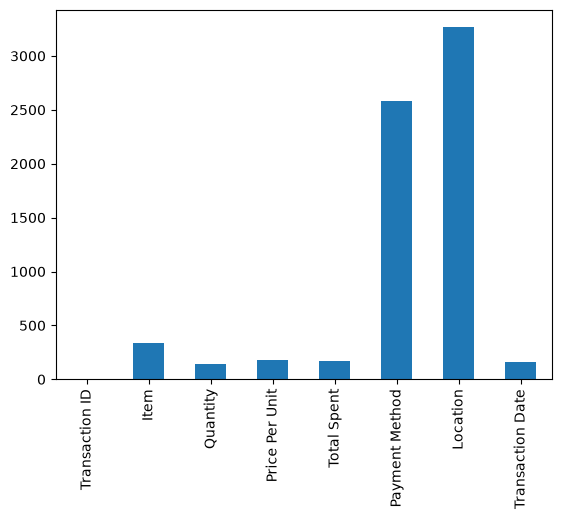

In [46]:
#  Your code here
#1
print(df.isnull().sum())
#2
tong_missing = df.isnull().sum().sum()
tong_dong = df.shape[0]
percent_missing = (tong_missing / tong_dong) * 100
print("% trên tổng dataset: ", percent_missing)

#3
df.isnull().sum().plot(kind='bar')




---
## Phần 2 — Data Cleaning (**3,5 đ**)



### Câu 2.1 — Handle missing values (**1,5 đ**)

Làm theo **từng cột** ở bảng dưới. Sau khi xử lý, in lại số missing để kiểm tra.

| Cột | Loại | Cách xử lý |
|---|---|---|
| Transaction ID | ID | Thiếu thì **xóa dòng** (không suy ra được) |
| Quantity | Số | Nếu đủ Price Per Unit và Total Spent → Quantity = Total Spent / Price Per Unit. Phần còn thiếu → **median** |
| Price Per Unit | Số | Nếu đủ Quantity và Total Spent → Price Per Unit = Total Spent / Quantity. Phần còn thiếu → **median** |
| Total Spent | Số | Nếu đủ Quantity và Price Per Unit → Total Spent = Quantity × Price Per Unit. Phần còn thiếu → **median** |
| Item | Nhóm | Fill missing — chọn cách ở bước 3 |
| Payment Method | Nhóm | Fill missing — chọn cách ở bước 3 |
| Location | Nhóm | Fill missing — chọn cách ở bước 3 |
| Transaction Date | Ngày | Chưa fill ở câu này — convert ở câu 2.2 |


**Bước 1 — Đổi giá trị giả thành missing (**0,3 đ**)**

Trên mọi cột: ERROR và UNKNOWN không phải dữ liệu thật → đổi thành NaN, rồi mới fill.
Áp dụng cho: Item, Quantity, Price Per Unit, Total Spent, Payment Method, Location, Transaction Date.

In [47]:
# Your code here --> replace
df['Item'] = df['Item'].replace(['ERROR','UNKNOWN'],np.nan)
df['Item']
df['Quantity'] = df['Quantity'].replace(['ERROR','UNKNOWN'],np.nan)
df['Price Per Unit'] = df['Price Per Unit'].replace(['ERROR','UNKNOWN'],np.nan)
df['Total Spent'] = df['Total Spent'].replace(['ERROR','UNKNOWN'],np.nan)
df['Payment Method'] = df['Payment Method'].replace(['ERROR','UNKNOWN'],np.nan)
df['Location'] = df['Location'].replace(['ERROR','UNKNOWN'],np.nan)
df['Transaction Date'] = df['Transaction Date'].replace(['ERROR','UNKNOWN'],np.nan)


In [48]:
df[['Item','Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']].head(10)

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,NaN,3,3.0,9.0,NaN,Takeaway,2023-10-06
7,Sandwich,4,4.0,16.0,Cash,NaN,2023-10-28
8,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


Fill numeric columns with median or mean. (1đ)

Ưu tiên **suy ra** Quantity / Price / Total từ 2 trong 3 cột (vì Total ≈ Quantity × Price), rồi mới fill median cho phần còn thiếu. Median bền hơn mean với dữ liệu lệch.

**Ví dụ số**

| Trường hợp | Quantity | Price Per Unit | Total Spent | Công thức |
|---|---|---|---|---|
| Thiếu Total | 2 | 5 | NaN | Total = 2 × 5 = 10 |
| Thiếu Quantity | NaN | 5 | 10 | Quantity = 10 / 5 = 2 |
| Thiếu Price | 2 | NaN | 10 | Price = 10 / 2 = 5 |
| Thiếu 2–3 cột | NaN | NaN | 10 | Không suy được → fill median |

**Mẫu code:** 3 trường hợp suy ra + 1 dòng fill median. Gỡ dấu # rồi chạy.

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9031 non-null   str  
 2   Quantity          9521 non-null   str  
 3   Price Per Unit    9467 non-null   str  
 4   Total Spent       9498 non-null   str  
 5   Payment Method    6822 non-null   str  
 6   Location          6039 non-null   str  
 7   Transaction Date  9540 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


Price, Total, Quantity đang để ở str => đổi sang float mới tính được 

In [50]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

coerce là không chuyển được về float là chuyển về NaN

In [51]:
# 1) Thiếu Total Spent, còn Quantity và Price → nhân
mask_total = df["Total Spent"].isna() & df["Quantity"].notna() & df["Price Per Unit"].notna()
df.loc[mask_total, "Total Spent"] = df.loc[mask_total, "Quantity"] * df.loc[mask_total, "Price Per Unit"]

# 2) Thiếu Quantity, còn Total và Price → chia
mask_quantity = df["Quantity"].isna() & df["Total Spent"].notna() & df["Price Per Unit"].notna()
df.loc[mask_quantity, "Quantity"] = df.loc[mask_quantity, "Total Spent"] / df.loc[mask_quantity, "Price Per Unit"]

# 3) Thiếu Price, còn Total và Quantity → chia
mask_price = df["Price Per Unit"].isna() & df["Quantity"].notna() & df["Total Spent"].notna()
df.loc[mask_price, "Price Per Unit"] = df.loc[mask_price, "Total Spent"] * df.loc[mask_price, "Quantity"]

# 4) Còn NaN thì fill median (làm tương tự 3 cột số)
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Total Spent"] = df["Total Spent"].fillna(df["Total Spent"].median())
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit"].median())


# Your code here

**Bước 3 — Cột nhóm (**0,4 đ**)** — Item, Payment Method, Location

Fill NaN bằng Unknown. 

**Mẫu code** (chỉ cột Item). Làm tương tự cho Payment Method và Location.

In [52]:
# Mẫu: fill Item
df["Item"] = df["Item"].fillna("Unknown")
df["Payment Method"] = df["Payment Method"].fillna("Unknown")
df["Location"] = df["Payment Method"].fillna("Unknown")
# Your code here


**Bonus** Tại sao không fill mode: 3 cột này ? (+0.5)

# your explaination here
Mode tức giá trị xuất hiện nhiều nhất, không nên sửu dụng cách này vì có thể làm sai lêch thông tin trên bảng dữ liệu.Unknown ở đây là 1 nhãn cho dữ liệu thiếu, không phải mình đoán giá trị thiếu là gì

### Câu 2.2 — Fix incorrect data types (**0,8 đ**)

**Yêu cầu — convert:**
- Quantity → integer
- Price Per Unit, Total Spent → float
- Transaction Date → datetime

**Hướng dẫn làm**
- Số: astype.
- Ngày: to_datetime, lỗi thì thành NaT.
- In dtypes sau khi convert.



In [53]:
#  Your code here
df['Quantity'] = df['Quantity'].to_numpy('int')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  str    
 1   Item              10000 non-null  str    
 2   Quantity          10000 non-null  int64  
 3   Price Per Unit    10000 non-null  float64
 4   Total Spent       10000 non-null  float64
 5   Payment Method    10000 non-null  str    
 6   Location          10000 non-null  str    
 7   Transaction Date  9540 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 625.1 KB


### Câu 2.3 —  Create new features (**1,2 đ**)

**Yêu cầu**
1. Tách Year, Month, Day of week từ Transaction Date (**0,6 đ**).
2. Total Spent ≈ Quantity × Price Per Unit (**0,6 đ**).



In [54]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [55]:
# Your code here
#1
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month
df['Day of week'] = df['Transaction Date'].dt.day_of_week

df[['Transaction Date', 'Year', 'Month', 'Day of week']].head()


#2 
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']

df['Total Spent']

0        4.0
1       12.0
2        4.0
3       10.0
4        4.0
        ... 
9995     4.0
9996    27.0
9997     8.0
9998    27.0
9999    12.0
Name: Total Spent, Length: 10000, dtype: float64

---
## Phần 3 — Exploratory Data Analysis (**3,0 đ**)

Làm EDA trên dữ liệu đã clean.

### Câu 3.1 — Món bán chạy (**1,0 đ**)

**Yêu cầu**
1. Bảng top 5 Item theo tổng Quantity (**0,5 đ**).
2. Bar plot top 5 (**0,5 đ**).

**Hướng dẫn làm**
- Group theo Item, cộng Quantity, sắp xếp giảm dần, lấy 5 món đầu.
- Bar plot: có title và nhãn trục.
- Nếu đã fill Unknown: ghi 1 dòng lý do có/không loại Unknown khỏi top 5.



Text(0, 0.5, 'số lượng')

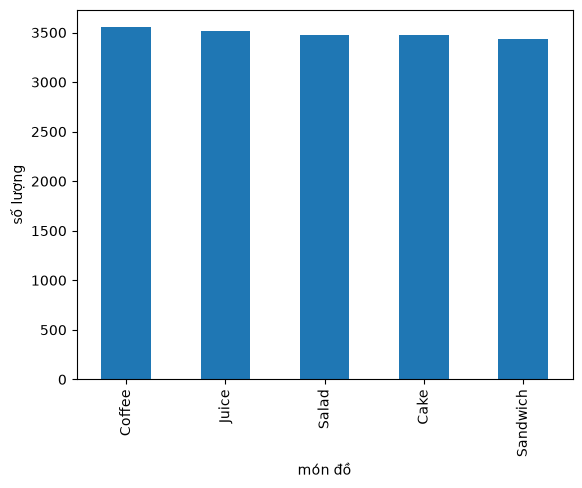

In [56]:
# Your code here
#1
top5 = df.groupby('Item')['Quantity'].sum().nlargest(5)

top5

top5.plot(kind='bar')
plt.xlabel('món đồ')
plt.ylabel('số lượng')

In [57]:
top5


Item
Coffee      3552
Juice       3514
Salad       3477
Cake        3474
Sandwich    3439
Name: Quantity, dtype: int64

### Câu 3.2 — Outlier (**1,0 đ**)

**Yêu cầu**
1. Boxplot Quantity và/hoặc Total Spent (**0,5 đ**).
2. Quyết định keep / cap / remove và giải thích (**0,5 đ**).

**Hướng dẫn làm**
- Dùng boxplot.
- Có thể dùng IQR: Q1 và Q3 là quantile 0.25 và 0.75; fence = Q1 − 1.5×IQR và Q3 + 1.5×IQR.


<Axes: ylabel='Quantity'>

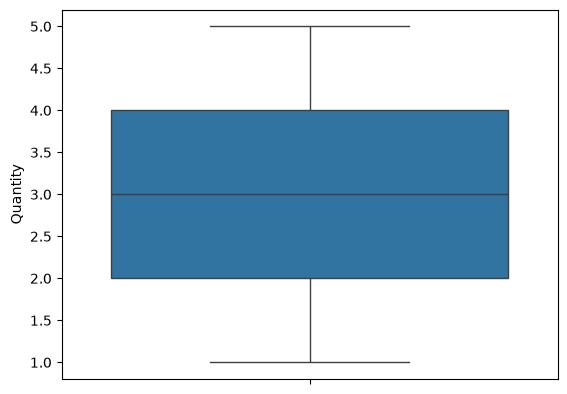

In [58]:
# Your code here
sns.boxplot(df['Quantity'])

<Axes: ylabel='Total Spent'>

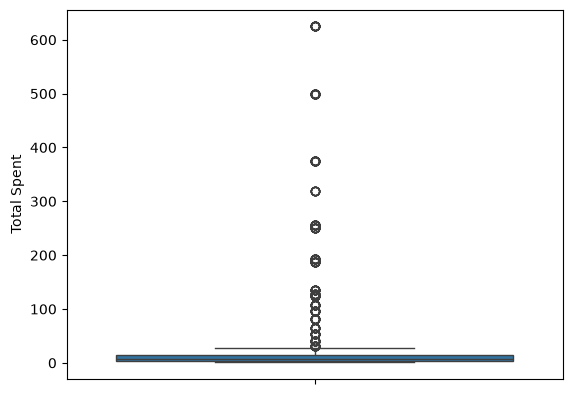

In [59]:
sns.boxplot(df['Total Spent'])

**Bonus (+0,25 đ**): Điểm khác biệt giữa IQR và clip là gì?.

In [60]:
# your explaination here

IQR = tìm giới hạn để xác định outlier
clip = ép giá trị nằm trong giới hạn đó

SyntaxError: invalid syntax (2298715386.py, line 3)

### Câu 3.3 — Correlation (**1,0 đ**)

**Yêu cầu**
1. Ma trận tương quan các cột số Quantity, Price Per Unit, Total Spent (**0,3 đ**).
2. Heatmap (**0,3 đ**).
3. Viết mối quan hệ nổi bật (**0,4 đ**).

**Hướng dẫn làm**
- Nhận xét từng cặp: dương/âm, mạnh/yếu.
Quantity và Price Per Unit có tương quan dương yếu (r = 0,14).


,Quantity,Price Per Unit,Total Spent
Quantity,1.000000,0.140112,0.233598
Price Per Unit,0.140112,1.000000,0.984454
Total Spent,0.233598,0.984454,1.000000


<Axes: >

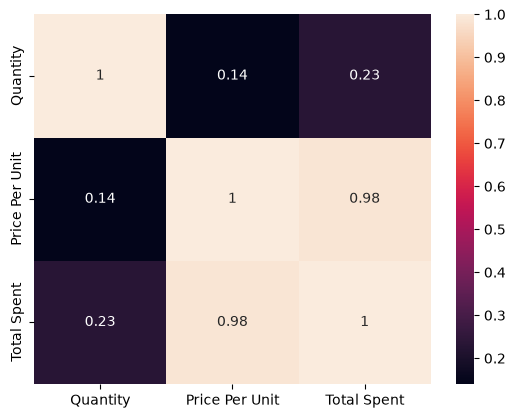

In [65]:
# Your code here
#1
corr = df[['Quantity', 'Price Per Unit', 'Total Spent']].corr()

display(corr)

#2
sns.heatmap(corr,annot = True)



#3
 Quantity và Total Spent có tương quan dương yếu (r = 0,23). Price Per Unit và Total Spent có tương quan dương rất mạnh (r = 0,98).

---
## Phần 4 — Summary & Insights (**1,0 đ**)

### Câu 4.1 (**1,0 đ**)

Điền vào khung bên dưới. Lấy số từ output bạn đã chạy. Không bịa số.


In [66]:
# (1) Tỷ lệ thiếu toàn bộ dataset
missing_percent = df.isna().sum().sum() / df.size * 100

# Cột thiếu nhiều nhất
missing_col = df.isna().sum().idxmax()
missing_col_percent = df[missing_col].isna().mean() * 100

print(missing_percent)
print(missing_col, missing_col_percent)

1.6727272727272726
Transaction Date 4.6


**Câu 4.1 — điền vào chỗ trống**

(1) Toàn bộ dataset thiếu khoảng 1,67%. Cột thiếu nhiều nhất là Transaction Date (khoảng 4,6%).
Cột số em fill bằng median; cột nhóm em fill bằng Unknown.
Ý nghĩa: Dataset có tỷ lệ thiếu thấp, dữ liệu sau xử lý vẫn phù hợp để phân tích.

(2) Top 1 theo tổng Quantity là Coffee, khoảng 3522 đơn vị.
Em có loại Unknown khỏi bảng top 5 không? Có.
Lý do: Unknown không phải tên món thực tế nên loại để kết quả phản ánh đúng món bán chạy.
Ý nghĩa: Quán nên ưu tiên nguồn hàng và quảng bá Coffee vì đây là món bán chạy nhất.

(3) Tương quan: Price Per Unit và Total Spent có corr ≈ 0,98 (dương, rất mạnh).
Ý nghĩa: Giá mỗi đơn vị càng cao thì Total Spent có xu hướng càng cao.


---
## Bonus — Encoding (**+0,5 đ**)

**Yêu cầu**
1. One-hot 1–2 cột category ít nhóm (ví dụ Payment Method, Location). Giữ cột gốc.
2. Label encoding cột nhiều nhóm hơn (ví dụ Item). Nói rõ số không có thứ tự.

**Hướng dẫn làm**
- One-hot: get_dummies rồi nối lại dataframe.
- Label: LabelEncoder, tạo cột mới (ví dụ Item_label).


In [69]:
# Bonus — Your code here (optional)
dummies = pd.get_dummies(df['Payment Method'], prefix='Payment')
df = pd.concat([df, dummies], axis=1)

display(df.head())
#2


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Item_label'] = le.fit_transform(df['Item'])
df['Item_label']


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,...,Payment_Unknown,Item_label,Payment_Cash,Payment_Credit Card,Payment_Digital Wallet,Payment_Unknown,Payment_Cash,Payment_Credit Card,Payment_Digital Wallet,Payment_Unknown
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Credit Card,2023-09-08,2023.0,9.0,...,False,1,False,True,False,False,False,True,False,False
1,TXN_4977031,Cake,4,3.0,12.0,Cash,Cash,2023-05-16,2023.0,5.0,...,False,0,True,False,False,False,True,False,False,False
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,Credit Card,2023-07-19,2023.0,7.0,...,False,2,False,True,False,False,False,True,False,False
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27,2023.0,4.0,...,True,4,False,False,False,True,False,False,False,True
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,Digital Wallet,2023-06-11,2023.0,6.0,...,False,1,False,False,True,False,False,False,True,False


0       1
1       0
2       2
3       4
4       1
       ..
9995    1
9996    8
9997    1
9998    2
9999    5
Name: Item_label, Length: 10000, dtype: int64